### `Fish Species Prediction Analysis`

`Fish Species Classification Predictive Model Using Various Measurements`

`Loading Libraries`

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns; sns.set_theme()
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, auc, roc_auc_score, roc_curve, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

`Loading dataset`

In [106]:
fish_species = pd.read_csv('../dataset/Fish.csv')
fish_species.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


`Renaming columns for proper identification`

In [107]:
fish_species = fish_species.rename(columns={'Length1': 'Vertical Length', 'Length2': 'Diagonal Length', 'Length3': 'Cross Length'})
fish_species.head()

,Species,Weight,Vertical Length,Diagonal Length,Cross Length,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


`Summary Statistics`

In [108]:
print(f'===== Shape of the Dataset =====')
fish_species.shape

===== Shape of the Dataset =====


(159, 7)

In [109]:
print(f'===== Information about the dataset ===== \n')
fish_species.info()

===== Information about the dataset ===== 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Species          159 non-null    object 
 1   Weight           159 non-null    float64
 2   Vertical Length  159 non-null    float64
 3   Diagonal Length  159 non-null    float64
 4   Cross Length     159 non-null    float64
 5   Height           159 non-null    float64
 6   Width            159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [110]:
fish_species.describe()

,Weight,Vertical Length,Diagonal Length,Cross Length,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


`Handling Missing Values`

In [111]:
fish_species.isnull().sum().sort_values(ascending=False)

Species            0
Weight             0
Vertical Length    0
Diagonal Length    0
Cross Length       0
Height             0
Width              0
dtype: int64

`Handling Outliers`

In [112]:
q1 = fish_species.select_dtypes(include=['number']).quantile(0.25)
q3 = fish_species.select_dtypes(include=['number']).quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'===== Lower Bound ===== \n {lower_bound}')
print(f'===== Upper Bound ===== \n {upper_bound}')

===== Lower Bound ===== 
 Weight            -675.000000
Vertical Length     -1.425000
Diagonal Length     -0.750000
Cross Length        -1.600000
Height              -3.686850
Width                0.087375
dtype: float64
===== Upper Bound ===== 
 Weight             1445.000000
Vertical Length      53.175000
Diagonal Length      57.250000
Cross Length         64.400000
Height               21.997550
Width                 8.882775
dtype: float64


In [113]:
for col in fish_species.select_dtypes(include=['number']):
    mask = (fish_species[col] < lower_bound[col]) | (fish_species[col] > upper_bound[col])
    count = mask.sum()
    if count > 0:
        print(f'{col}: {count} outliers | '
              f'bounds = [{lower_bound[col]:.2f}, {upper_bound[col]:.2f}] | '
              f'actual min={fish_species[col].min():.2f}, actual max={fish_species[col].max():.2f}'
              )

Weight: 3 outliers | bounds = [-675.00, 1445.00] | actual min=0.00, actual max=1650.00
Vertical Length: 3 outliers | bounds = [-1.43, 53.18] | actual min=7.50, actual max=59.00
Diagonal Length: 3 outliers | bounds = [-0.75, 57.25] | actual min=8.40, actual max=63.40
Cross Length: 1 outliers | bounds = [-1.60, 64.40] | actual min=8.80, actual max=68.00


`Visualizing Outliers`

In [114]:
plt.figure(figsize=(25, 7))

figure = px.box(fish_species.select_dtypes(include=['number']),
                title= 'Boxplot Outlier Visualization',
                orientation='h',
                ).show()

plt.show()

<Figure size 2500x700 with 0 Axes>

`Winsorization` Capping Outiler Values with Boundary

In [115]:
for col in fish_species.select_dtypes(include=['number']):
    q1 = fish_species[col].quantile(0.25)
    q3 = fish_species[col].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

fish_species[col] = fish_species[col].clip(lower_bound, upper_bound)


`Data Visualization`

In [116]:
plt.figure(figsize=(25, 6))
figure = px.bar(fish_species, x = fish_species['Species'],
                color = fish_species['Weight'],
                title = 'Species Distribution By Weight Chart').show()
plt.show()

<Figure size 2500x600 with 0 Axes>

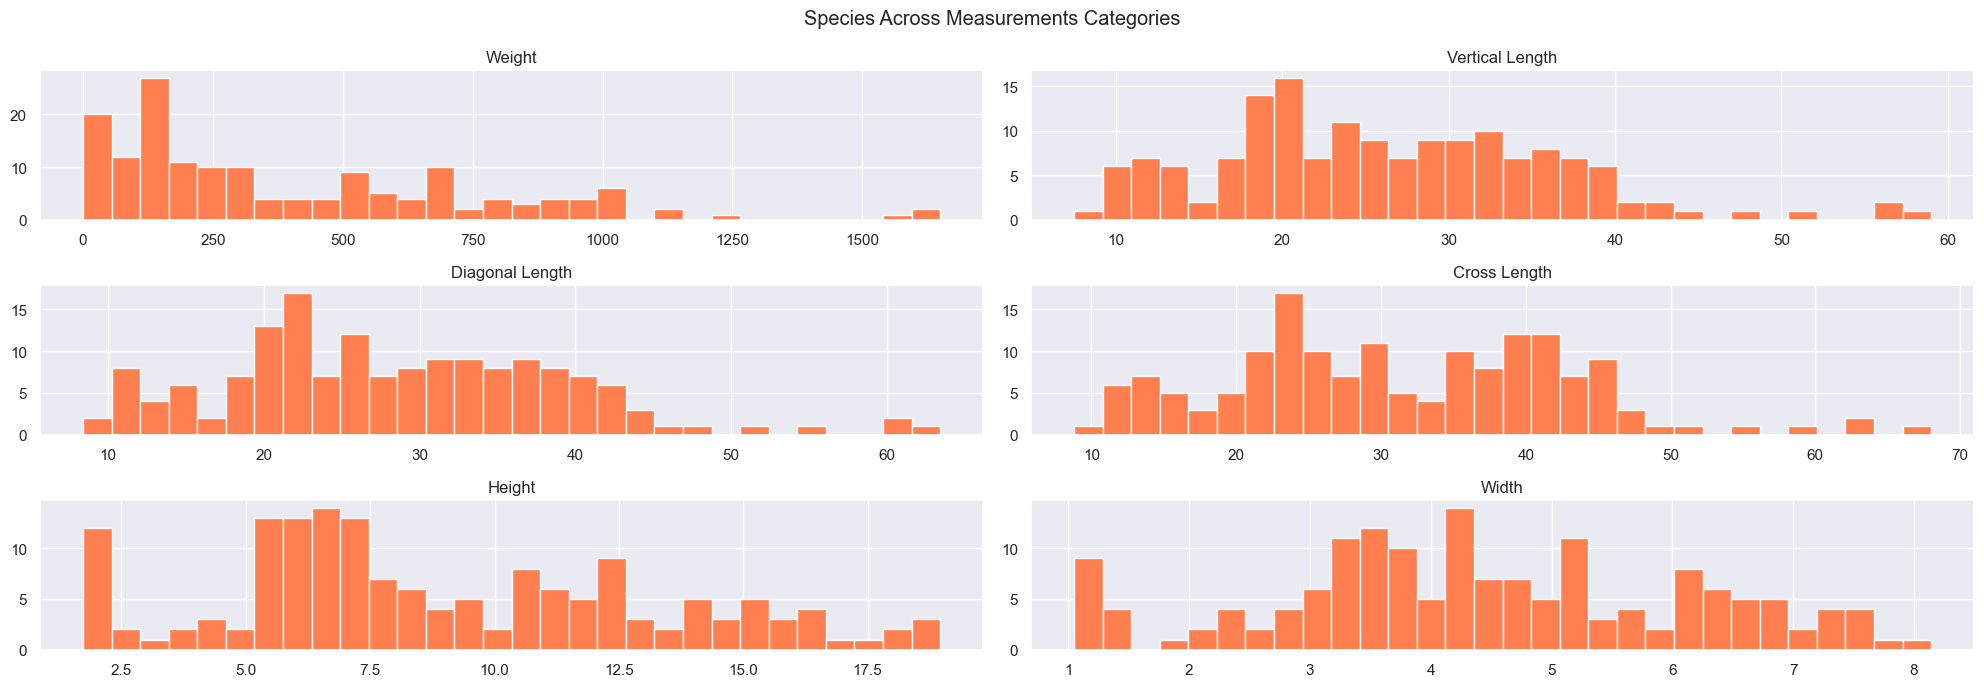

In [117]:
fish_species.hist(bins=30, figsize=(20, 7), color='coral', edgecolor='white')
plt.suptitle('Species Across Measurements Categories')
plt.tight_layout()
plt.show()

In [118]:
species = fish_species['Species'].value_counts()
labels = species.index
values = species.values
colors = ['green', 'blue']

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=0.5)])
fig.update_layout(title_text = 'Number of Fish Species')
fig.update_traces(hoverinfo='label+percent', textinfo='value', marker=dict(colors=colors))

fig.show()

`HeatMap Feature Correlation Plot`

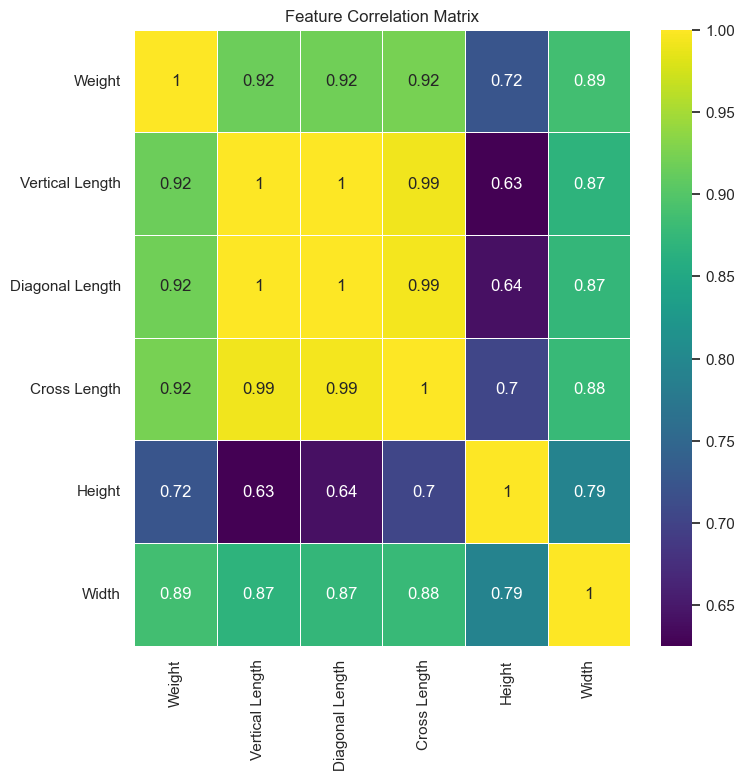

In [119]:
corr_matrix = fish_species.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, linewidths=0.5, cmap='viridis')
plt.title('Feature Correlation Matrix')
plt.show()

`Feature Selection and Data Splitting`

In [120]:
X = fish_species.drop(columns=['Species'], axis=1)
y = fish_species['Species']


`Encoding Target Categorical Column` using `LabelEncoder`

In [121]:
le = LabelEncoder()
y = le.fit_transform(y)

`Data Splitting`

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42, stratify=y)

#### `Logistic Regression`

In [125]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])

lr_pipe.fit(X_train, y_train)
lr_y_pred = lr_pipe.predict(X_test)
print(lr_y_pred)

[4 1 3 3 0 0 6 0 6 4 4 0 2 1 0 4 4 4 0 5 4 4 4 3 5 1 0 0 4 4 6 1 4 4 3 4 4
 4 5 0 3 1 0 5 4 4 0 2 0 1 4 1 1 0 2 0 4 0 4 4 2 0 4 6 2 1 5 4 4 6 4 1 4 0
 4 4 4 5 0 0 3 4 6 2 0 4 6 4 4 4 4 5 4 4 2 5 0 0 4 5 4 2 4 5 4 4 2 2 4 0 0
 6 1 5 6 4 4 5 4 4 3 3 1 5 6 5 0 4]


In [ ]:
lr_model = {
    'LOGISTIC REGRESSION': lr_pipe
}

for name, model in lr_model.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    lr_y_pred = model.predict(X_test)
    lr_y_prob = model.predict_proba(X_test)[:, 1]

# train and test scores
print(f'\n{name}\n')
print(f'\n ===== Train Score ===== \n {train_score:.4f}')
print(f'\n ===== Test Score ===== \n {test_score:.4f}')


# model accuracy 
accuracy = accuracy_score(y_test, lr_y_pred)
print(f'\n ===== Accuracy Score ===== \n {accuracy:.4f}')

# prediction probabilities
print(f'\n ===== Prediction Probabilities ===== \n {lr_y_prob[:10]}')

# classification report
print(f'\n ===== Classification Report ===== \n {classification_report(y_test, lr_y_pred)}')

# confusion matrix
cm = confusion_matrix(y_test, lr_y_pred)
print(f'\n ===== Confusion Matrix ===== \n {cm}')

# roc auc score
lr_y_prob = model.predict_proba(X_test)
ras = roc_auc_score(y_test, lr_y_prob, multi_class='ovr', average='macro')
print(f'\n ===== ROC Auc Score ===== \n {ras:.4f}')

# logistic regression cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(lr_pipe, X, y, cv=skf, scoring='accuracy')
print(f'\n ==== Logistic Regression Cross Validation ==== \n {lr_cv}')
print(f'\n ==== Mean / Standard Deviation Cross Validation ==== \n {lr_cv.mean():.3f} (+/-) {lr_cv.std() * 2:.3f}')


LOGISTIC REGRESSION


 ===== Train Score ===== 
 0.6774

 ===== Test Score ===== 
 0.6094

 ===== Accuracy Score ===== 
 0.6094

 ===== Prediction Probabilities ===== 
 [0.18369423 0.4443045  0.00103385 0.01651693 0.29009206 0.23922761
 0.01203277 0.07956942 0.01474428 0.04810014]

 ===== Classification Report ===== 
               precision    recall  f1-score   support

           0       1.00      0.89      0.94        28
           1       0.75      1.00      0.86         9
           2       0.90      0.20      0.33        45
           3       1.00      0.57      0.73        14
           4       0.31      0.94      0.46        16
           5       0.79      1.00      0.88        11
           6       0.10      0.20      0.13         5

    accuracy                           0.61       128
   macro avg       0.69      0.69      0.62       128
weighted avg       0.81      0.61      0.60       128


 ===== Confusion Matrix ===== 
 [[25  3  0  0  0  0  0]
 [ 0  9  0  0  0  0  0]
 

`Confusion Matrix`

<Figure size 1000x1000 with 0 Axes>

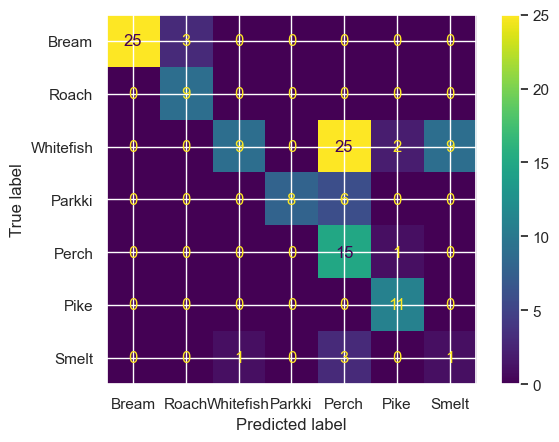

In [ ]:
plt.figure(figsize=(10, 10))
cm = confusion_matrix(y_test, lr_y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'])
display.plot(cmap='viridis')
plt.show()

`Roc Curve Display` using `(One-vs-Rest)` for `Multiclass Target Column` 

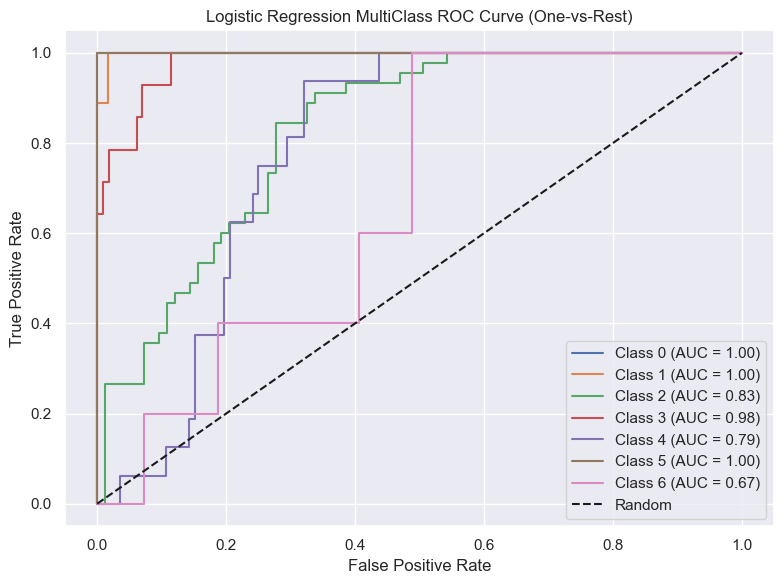

In [ ]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], lr_y_prob[:, i])
    lr_roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {lr_roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression MultiClass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()